# FDR confidence

In [2]:
# new_get_wiki_data.py
#
# Description: This script retrieves and processes mass spectrometry data from MassWiki.
#              It includes functions for filtering results and querying spectral library hits.
#
# Author: Adapted from zyang2k's R script
# Last Modified: 2025-01-23

#------------------------------------------------------------------------------
# Required Packages
#------------------------------------------------------------------------------
import pandas as pd  # For data manipulation
import requests  # For HTTP requests
import json  # For JSON parsing
import urllib.parse  # For URL encoding

#------------------------------------------------------------------------------
# Function Definitions
#------------------------------------------------------------------------------

def filter_masswiki_results(masswiki_result):
    """
    Filter mass spectrometry results based on specific criteria:
    1. Keeps only manually annotated entries
    2. Removes entries with names starting with 'yy' or 'zz'

    Args:
        masswiki_result (pd.DataFrame): A DataFrame containing MassWiki results
            with columns including 'is_manual_annotated' and 'name'

    Returns:
        pd.DataFrame: Filtered results containing only manually annotated entries
            with valid names
    
    Examples:
        filtered_data = filter_masswiki_results(raw_results)
    """
    # Create a copy to avoid SettingWithCopyWarning
    df = masswiki_result.copy()
    
    # Convert 'name' column to string, replacing NaNs with empty string
    df['name'] = df['name'].astype(str).fillna('')
    
    # Ensure 'is_manual_annotated' is boolean, replacing NaNs with False
    df['is_manual_annotated'] = df['is_manual_annotated'].fillna(False).astype(bool)
    
    # Filter manually annotated entries and exclude names starting with 'yy' or 'zz'
    filtered_result = df[
        (df['is_manual_annotated'] == True) & 
        (~df['name'].str.lower().str.startswith(('yy', 'zz')))
    ]
    
    return filtered_result
import requests
import urllib.parse

def get_spectrum_data(wiki_ids):
    """
    Retrieve spectral data for given wiki IDs from the MassWiki API.

    The function handles multiple wiki IDs and includes error handling for API requests.

    Args:
        wiki_ids (list): A list of wiki IDs to query

    Returns:
        dict: A nested dictionary where each key is a wiki_id and contains:
            - target_spectrum: Information about the queried target spectrum
            - reference_library: Results from reference library identity search
            - annotation_library: Results from annotation library identity search
            Returns None for entries where the API request failed

    Details:
    1. Processes each wiki_id individually
    2. Skips empty or None wiki_ids
    3. URL encodes the wiki_ids to handle special characters
    4. Makes GET requests to the MassWiki API
    5. Parses target spectrum data, reference library results, and annotation library results

    Examples:
        results = get_spectrum_data(['wiki_id_1', 'wiki_id_2'])
    """
    # Ensure wiki_ids is a list and remove any None or empty string values
    wiki_ids = [str(wiki_id) for wiki_id in wiki_ids if wiki_id]
    
    # Initialize results dictionary
    all_results = {}
    
    session = requests.Session()

    # Process each wiki_id
    for wiki_id in wiki_ids:
        try:
            # URL encode the wiki_id to handle special characters
            encoded_wiki_id = urllib.parse.quote(wiki_id, safe='')
            url = f'https://masswiki.us-west-2.elasticbeanstalk.com/analysis/get_data?wiki_id={encoded_wiki_id}'
            
            # Make the API request
            response = session.get(url, headers={'Accept': 'application/json'}, timeout=60)  # 60 seconds

            # Check if the request was successful
            if response.status_code == 200:
                data = response.json()
                
                results = {
                    "target_spectrum": None,
                    "reference_library": None,
                    "annotation_library": None
                }

                # Extract target spectrum details if available
                if "spectrum" in data:
                    spectrum = data["spectrum"]
                    results["target_spectrum"] = {
                        "scan": spectrum.get("scan"),
                        "splash": spectrum.get("splash"),
                        "name": spectrum.get("name"),
                        "adduct": spectrum.get("adduct"),
                        "spec_uid": spectrum.get("spec_uid"),
                        "charge": spectrum.get("charge"),
                        "precursor_mz": spectrum.get("precursor_mz"),
                        "entropy": spectrum.get("entropy"),
                        "rt_normalized": spectrum.get("rt_normalized"),
                        "rt": spectrum.get("rt")
                    }

                # Extract reference library identity search results if they exist
                if data.get('analysis', {}).get('reference_library', {}).get('identity_search'):
                    results['reference_library'] = data['analysis']['reference_library']['identity_search']
                
                # Extract annotation library identity search results if they exist
                if data.get('analysis', {}).get('annotation_library', {}).get('identity_search'):
                    results['annotation_library'] = data['analysis']['annotation_library']['identity_search']
                
                all_results[wiki_id] = results
                
            else:
                print(f"Failed to get spectrum data for {wiki_id}. Status code: {response.status_code}")
                all_results[wiki_id] = None
        
        except Exception as e:
            print(f"Error processing wiki_id: {wiki_id} - {str(e)}")
            all_results[wiki_id] = None

    session.close()
    
    return all_results

# Example usage:
# results = get_spectrum_data(["aPUDE1U/726", "aPUDE1U/19"])
# print(results)


#------------------------------------------------------------------------------
# Usage Notes:
# 1. Ensure all required packages are installed:
#    pip install pandas requests
# 2. Verify that input CSV files exist in the data/ directory
# 3. Check internet connection for API requests
# 4. Consider implementing rate limiting for large numbers of API requests
# 5. Monitor API response times and implement appropriate timeout settings
#------------------------------------------------------------------------------

# Example usage (uncomment and modify as needed)
# def main():
#     # Read input data
#     raw_data = pd.read_csv('data/input_file.csv')
#     
#     # Filter results
#     filtered_data = filter_masswiki_results(raw_data)
#     
#     # Get spectrum data
#     spectrum_results = get_spectrum_data(filtered_data['wiki_id'].tolist())
#     
#     # Further processing can be done here
# 
# if __name__ == '__main__':
#     main()

In [3]:
wiki_neg = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_pre_orb_neg.csv')
wiki_pos = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_pre_orb_pos.csv')

In [17]:
wiki_neg_ids = wiki_neg['wiki_id'].tolist()
wiki_pos_ids = wiki_pos['wiki_id'].tolist()

# Get spectrum data for those IDs
wiki_neg_matches = get_spectrum_data(wiki_neg_ids)
wiki_pos_matches = get_spectrum_data(wiki_pos_ids)

Error processing wiki_id: aEKJ9AS/475 - HTTPSConnectionPool(host='masswiki.us-west-2.elasticbeanstalk.com', port=443): Read timed out. (read timeout=60)
Error processing wiki_id: aEKJ9AS/476 - HTTPSConnectionPool(host='masswiki.us-west-2.elasticbeanstalk.com', port=443): Read timed out. (read timeout=60)
Failed to get spectrum data for aEKJ9AS/477. Status code: 502
Failed to get spectrum data for aEKJ9AS/478. Status code: 502
Failed to get spectrum data for aEKJ9AS/479. Status code: 502
Failed to get spectrum data for aEKJ9AS/480. Status code: 502
Failed to get spectrum data for aEKJ9AS/481. Status code: 502
Failed to get spectrum data for aEKJ9AS/482. Status code: 502
Failed to get spectrum data for aEKJ9AS/483. Status code: 502
Failed to get spectrum data for aEKJ9AS/484. Status code: 502
Failed to get spectrum data for aEKJ9AS/485. Status code: 502
Failed to get spectrum data for aEKJ9AS/486. Status code: 502
Failed to get spectrum data for aEKJ9AS/487. Status code: 502
Failed to ge

In [18]:
def convert_spectrum_data_to_dataframe_with_source(spectrum_data):
    """
    Converts the structured dictionary of spectrum data into a Pandas DataFrame with a source indicator.

    Args:
        spectrum_data (dict): Dictionary containing target spectrum, reference library, and annotation library data.

    Returns:
        pd.DataFrame: A structured DataFrame containing all extracted data with a source indicator.
    """
    data = []

    for wiki_id, entry in spectrum_data.items():
        if entry is None:
            continue  # Skip if the entry is None (failed API request)

        # Extract target spectrum details
        target_spectrum = entry.get("target_spectrum", {})
        ref_library = entry.get("reference_library", [])
        ann_library = entry.get("annotation_library", [])

        # Ensure reference and annotation library matches are lists
        ref_library = ref_library if isinstance(ref_library, list) else []
        ann_library = ann_library if isinstance(ann_library, list) else []

        # Process reference library matches
        for match in ref_library:
            data.append([
                wiki_id,
                target_spectrum.get("scan"),
                target_spectrum.get("splash"),
                target_spectrum.get("name"),
                target_spectrum.get("adduct"),
                target_spectrum.get("spec_uid"),
                target_spectrum.get("charge"),
                target_spectrum.get("precursor_mz"),
                target_spectrum.get("entropy"),
                target_spectrum.get("rt_normalized"),
                target_spectrum.get("rt"),
                match.get("db"),
                match.get("id"),
                match.get("name"),
                match.get("adduct"),
                match.get("rt"),
                match.get("smiles"),
                match.get("spec_uid"),
                match.get("precursor_mz"),
                match.get("entropy_similarity"),
                "reference_library"  # Source indicator
            ])

        # Process annotation library matches
        for match in ann_library:
            data.append([
                wiki_id,
                target_spectrum.get("scan"),
                target_spectrum.get("splash"),
                target_spectrum.get("name"),
                target_spectrum.get("adduct"),
                target_spectrum.get("spec_uid"),
                target_spectrum.get("charge"),
                target_spectrum.get("precursor_mz"),
                target_spectrum.get("entropy"),
                target_spectrum.get("rt_normalized"),
                target_spectrum.get("rt"),
                match.get("db"),
                match.get("id"),
                match.get("name"),
                match.get("adduct"),
                match.get("rt"),
                match.get("smiles"),
                match.get("spec_uid"),
                match.get("precursor_mz"),
                match.get("entropy_similarity"),
                "annotation_library"  # Source indicator
            ])

    # Define column names for the DataFrame
    columns = [
        "wiki_id", "scan", "splash", "target_name", "target_adduct", "spec_uid",
        "charge", "precursor_mz", "entropy", "rt_normalized", "rt",
        "library_db", "library_id", "library_name", "library_adduct","library_rt", "library_smiles","library_spec_uid",
        "library_precursor_mz", "entropy_similarity", "source"
    ]

    # Convert to DataFrame
    spectrum_df = pd.DataFrame(data, columns=columns)

    return spectrum_df

# Example usage:
spectrum_df_neg = convert_spectrum_data_to_dataframe_with_source(wiki_neg_matches)
spectrum_df_pos = convert_spectrum_data_to_dataframe_with_source(wiki_pos_matches)

spectrum_df = pd.concat([spectrum_df_neg, spectrum_df_pos], ignore_index=True)


In [19]:
spectrum_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70668 entries, 0 to 70667
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wiki_id               70668 non-null  object 
 1   scan                  70668 non-null  int64  
 2   splash                70668 non-null  object 
 3   target_name           70668 non-null  object 
 4   target_adduct         70668 non-null  object 
 5   spec_uid              70668 non-null  int64  
 6   charge                70668 non-null  int64  
 7   precursor_mz          70668 non-null  float64
 8   entropy               70668 non-null  float64
 9   rt_normalized         70668 non-null  float64
 10  rt                    70668 non-null  float64
 11  library_db            70668 non-null  object 
 12  library_id            70668 non-null  object 
 13  library_name          70668 non-null  object 
 14  library_adduct        70668 non-null  object 
 15  library_rt         

In [20]:
true_pos_df = pd.read_csv("/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_test.csv")
training_set_df = pd.read_csv("/Users/ellayoung/Desktop/metabolo_confi_score/data/hilic_test.csv")


In [21]:
true_pos_df["match_type"] = "True Match"


In [22]:
# Rename `smiles` to `library_smiles` for merging
true_pos_df.rename(columns={"smiles": "library_smiles"}, inplace=True)
true_pos_df.rename(columns={"rt": "library_rt"}, inplace=True)



In [23]:
# Convert `library_rt` to float in all datasets
spectrum_df["library_rt"] = pd.to_numeric(spectrum_df["library_rt"], errors="coerce")
true_pos_df["library_rt"] = pd.to_numeric(true_pos_df["library_rt"], errors="coerce")


In [24]:
# Convert 'library_smiles' to 'match_type' mapping
true_pos_dict = true_pos_df.set_index("library_smiles")["match_type"].to_dict()


In [25]:
import pandas as pd

# Step 1: Map TN (True Negatives) based on the naming convention
spectrum_df["match_type"] = "Uncertain"  # Default to Uncertain
tn_mask = spectrum_df["target_name"].str.startswith(("yy_", "zz_"), na=False) | \
          spectrum_df["library_name"].str.startswith(("yy_", "zz_"), na=False)
spectrum_df.loc[tn_mask, "match_type"] = "False Match"  # Assign TN

# Step 2: Map TP (True Positives) without overriding TN
tp_mask = spectrum_df["library_smiles"].map(true_pos_dict).notna()
spectrum_df.loc[tp_mask & ~tn_mask, "match_type"] = spectrum_df["library_smiles"].map(true_pos_dict)


In [26]:
spectrum_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70668 entries, 0 to 70667
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wiki_id               70668 non-null  object 
 1   scan                  70668 non-null  int64  
 2   splash                70668 non-null  object 
 3   target_name           70668 non-null  object 
 4   target_adduct         70668 non-null  object 
 5   spec_uid              70668 non-null  int64  
 6   charge                70668 non-null  int64  
 7   precursor_mz          70668 non-null  float64
 8   entropy               70668 non-null  float64
 9   rt_normalized         70668 non-null  float64
 10  rt                    70668 non-null  float64
 11  library_db            70668 non-null  object 
 12  library_id            70668 non-null  object 
 13  library_name          70668 non-null  object 
 14  library_adduct        70668 non-null  object 
 15  library_rt         

In [16]:
# inspect false matches
# Filtering the dataframe to find all rows where match_type is 'False Match'
false_match_df = spectrum_df[spectrum_df['match_type'] == 'False Match']

false_match_df

,wiki_id,scan,splash,target_name,target_adduct,spec_uid,charge,precursor_mz,entropy,rt_normalized,...,library_id,library_name,library_adduct,library_rt,library_smiles,library_spec_uid,library_precursor_mz,entropy_similarity,source,match_type
425,aPUDE1U/12,12,splash10-004i-5900000000-a5f82ad9600221fb0c61,1_D4-Thymine iSTD_129.0608_23.40,,3225126395691211,-1,129.060760,1.440751,22.520246,...,7656833647418322,3-methyl-2-oxovaleric acid,[M-H]-,16.096857,CCC(C)C(=O)C(=O)O,3589956533580828,129.0557800042156,0.230484,annotation_library,False Match
426,aPUDE1U/12,12,splash10-004i-5900000000-a5f82ad9600221fb0c61,1_D4-Thymine iSTD_129.0608_23.40,,3225126395691211,-1,129.060760,1.440751,22.520246,...,4158904463861483,3-methyl-2-oxovaleric acid,[M-H]-,31.923438,CCC(C)C(=O)C(=O)O,1586333805526555,129.05579669851883,0.223533,annotation_library,False Match
527,aPUDE1U/14,14,splash10-000i-0900000000-41cfd52ada5876c57771,1_D3-DL-Aspartic acid iSTD,,4335486335695297,-1,135.049000,1.549304,136.487154,...,4103927095594980,phenylmalonic acid,[M-H-CO2]-,134.873447,C1=CC=C(C=C1)C(C(=O)O)C(=O)O,995681236897008,135.04909792565482,0.667585,annotation_library,False Match
1035,aPUDE1U/34,34,splash10-003r-8900000000-ae13ac4f077be9b8f5c9,erythronic acid,[M-H]-,1670011832415660,-1,135.029998,1.814195,117.603208,...,7232691953419639,erythronic acid,[M-H]-,117.189823,C(C(C(C(=O)O)O)O)O,1670011832415660,135.02999782833032,1.000000,annotation_library,False Match
1036,aPUDE1U/34,34,splash10-003r-8900000000-ae13ac4f077be9b8f5c9,erythronic acid,[M-H]-,1670011832415660,-1,135.029998,1.814195,117.603208,...,4990666097736567,erythronic acid,[M-H]-,113.131305,C(C(C(C(=O)O)O)O)O,1151309812849316,135.02994019077306,0.868092,annotation_library,False Match
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411057,aEKJ9AS/7427,7427,splash10-00di-9000000000-d28051198192b115f624,Pro-Val,[M+H]+,2137946480022130,1,215.139032,0.000000,92.466781,...,6762573688926937,Pro-Val,[M+H]+,92.031521,CC(C)C(C(=O)O)NC(=O)C1CCCN1,2137946480022130,215.13903209266587,1.000000,annotation_library,False Match
411058,aEKJ9AS/7427,7427,splash10-00di-9000000000-d28051198192b115f624,Pro-Val,[M+H]+,2137946480022130,1,215.139032,0.000000,92.466781,...,1092575539882373,zz Pro-Val_side peak,[M+H]+,85.951395,CC(C)C(C(=O)O)NC(=O)C1CCCN1,3168174163218875,215.1388977231208,0.872458,annotation_library,False Match
411060,aEKJ9AS/7427,7427,splash10-00di-9000000000-d28051198192b115f624,Pro-Val,[M+H]+,2137946480022130,1,215.139032,0.000000,92.466781,...,2298140472639124,Pro-Val,[M+H]+,109.938136,CC(C)C(C(=O)O)NC(=O)C1CCCN1,3964373676991025,215.13887862217655,0.403302,annotation_library,False Match
414419,aEKJ9AS/7496,7496,splash10-03di-5900000000-8532fb228fbde40dc0b6,ribavirin,[M+H-C5H8O4]+,294275410989388,1,113.053848,1.405542,99.750241,...,8054838001347084,"1,2-cyclohexanedione",[M+H]+,39.379645,C1CCC(=O)C(=O)C1,1876108924911466,113.05378686092838,0.912932,annotation_library,False Match


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


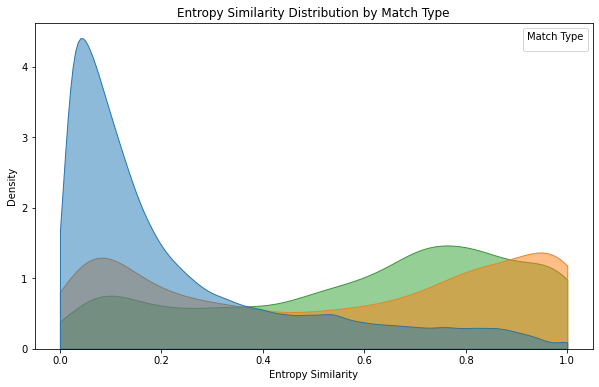

In [540]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot size
plt.figure(figsize=(10, 6))

# Plot KDE (Kernel Density Estimation) for each match_type
sns.kdeplot(data=spectrum_df, x="entropy_similarity", hue="match_type", fill=True, common_norm=False, alpha=0.5, clip=(0, 1))

# Labels and title
plt.xlabel("Entropy Similarity")
plt.ylabel("Density")
plt.title("Entropy Similarity Distribution by Match Type")

# Keep the legend
plt.legend(title="Match Type")

# Show plot
plt.show()


# Now I have a df with all matching information for hilic_pre_orb, and a label assigned to them

## Approach 1 FDR

In [386]:
false_matches_df

,wiki_id,scan,splash,target_name,target_adduct,spec_uid,charge,precursor_mz,entropy,rt_normalized,...,library_id,library_name,library_adduct,library_rt,library_smiles,library_spec_uid,library_precursor_mz,entropy_similarity,source,match_type
425,aPUDE1U/12,12,splash10-004i-5900000000-a5f82ad9600221fb0c61,1_D4-Thymine iSTD_129.0608_23.40,,3225126395691211,-1,129.060760,1.440751,22.520246,...,7656833647418322,3-methyl-2-oxovaleric acid,[M-H]-,16.096857,CCC(C)C(=O)C(=O)O,3589956533580828,129.0557800042156,0.230484,annotation_library,False Match
39825,aEKJ9AS/41,41,splash10-0a4i-9000000000-c63d3db0c72c93f26764,isopropanolamine,[M+H]+,2006817444739819,1,76.075637,0.318672,89.166748,...,5607545860096555,zz TMAO,[M+H]+,109.416147,C[N+](C)(C)[O-],2660692413168225,76.07570759343663,0.829022,annotation_library,False Match
39826,aEKJ9AS/41,41,splash10-0a4i-9000000000-c63d3db0c72c93f26764,isopropanolamine,[M+H]+,2006817444739819,1,76.075637,0.318672,89.166748,...,8627282265506343,zz TMAO,[M+H]+,101.004195,C[N+](C)(C)[O-],2637496862681605,76.07547843614756,0.828012,annotation_library,False Match
40085,aEKJ9AS/51,51,splash10-0udi-4900000000-b1df467f6a2274fa38af,triethylamine,[M+H]+,2044700745150751,1,102.127716,1.026269,38.176171,...,1697878975781025,zz,[M+H]+,10.511573,CCN(CC)CC,127107842208243,102.12773723133527,0.720728,annotation_library,False Match
89540,aEKJ9AS/779,779,splash10-014i-5090000000-afe846ee434da7a88d73,unknown_371.3269_68.79,,1509792881197718,1,371.326862,1.480486,69.124790,...,1564752412546330,myristamidopropyl betaine,[M]+,42.412142,CCCCCCCCCCCCCC(O)=NCCC[N+](C)(C)CC(=O)O,3740618781606747,371.3266748591588,0.719808,annotation_library,False Match
101365,aEKJ9AS/956,956,splash10-0a4i-9000000000-716b420f8812d900e606,TMAO,[M+H]+,3983975825720738,1,76.075753,0.687280,74.697367,...,5607545860096555,zz TMAO,[M+H]+,109.416147,C[N+](C)(C)[O-],2660692413168225,76.07570759343663,0.999998,annotation_library,False Match
101367,aEKJ9AS/956,956,splash10-0a4i-9000000000-716b420f8812d900e606,TMAO,[M+H]+,3983975825720738,1,76.075753,0.687280,74.697367,...,8627282265506343,zz TMAO,[M+H]+,101.004195,C[N+](C)(C)[O-],2637496862681605,76.07547843614756,0.999983,annotation_library,False Match
126558,aEKJ9AS/1429,1429,splash10-0udi-3900000000-be3e8853a6879f119ebf,hexylamine,[M+H]+,2098229659143170,1,102.127771,1.303667,28.231161,...,1697878975781025,zz,[M+H]+,10.511573,CCN(CC)CC,127107842208243,102.12773723133527,0.852637,annotation_library,False Match
137579,aEKJ9AS/1619,1619,splash10-00di-9220000000-45bf47e5166e0db03293,unknown_215.1390_112.66,,1265674625160395,1,215.139000,1.210120,112.988569,...,1092575539882373,zz Pro-Val_side peak,[M+H]+,85.951395,CC(C)C(C(=O)O)NC(=O)C1CCCN1,3168174163218875,215.1388977231208,0.630022,annotation_library,False Match
171602,aEKJ9AS/2424,2424,splash10-00di-2900000000-e69a55ccbaaa8b999d21,"N-methylbenzylamine_check RT, could also be zz...",[M+H]+,728244854570274,1,122.096419,1.194696,42.537386,...,4730348003604938,"N-methylbenzylamine_check RT, could also be zz...",[M+H]+,42.326704,CNCC1=CC=CC=C1,728244854570274,122.09641854655531,1.000000,annotation_library,False Match


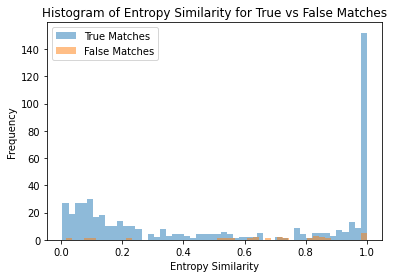

In [385]:
import matplotlib.pyplot as plt

plt.hist(spectrum_df[spectrum_df["match_type"] == "True Match"]["entropy_similarity"], bins=50, alpha=0.5, label="True Matches")
plt.hist(spectrum_df[spectrum_df["match_type"] == "False Match"]["entropy_similarity"], bins=50, alpha=0.5, label="False Matches")
plt.xlabel("Entropy Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.title("Histogram of Entropy Similarity for True vs False Matches")
plt.show()


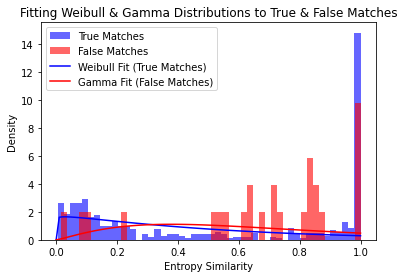

K-S Test for Weibull (True Matches): KstestResult(statistic=0.1934612418262015, pvalue=2.1616348412687728e-17, statistic_location=0.761613130569458, statistic_sign=-1)
K-S Test for Gamma (False Matches): KstestResult(statistic=0.29027238680502454, pvalue=0.019589836900479662, statistic_location=0.526394248008728, statistic_sign=-1)


In [387]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Extract entropy similarity values
true_scores = spectrum_df[spectrum_df["match_type"] == "True Match"]["entropy_similarity"].values
false_scores = spectrum_df[spectrum_df["match_type"] == "False Match"]["entropy_similarity"].values

# Fit Weibull distribution for True Matches
shape_weibull, loc_weibull, scale_weibull = stats.weibull_min.fit(true_scores, floc=0)

# Fit Gamma distribution for False Matches
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(false_scores, floc=0)

# Generate values for plotting
x = np.linspace(0, 1, 100)

# Plot histogram of actual entropy similarities
plt.hist(true_scores, bins=50, density=True, alpha=0.6, color='blue', label="True Matches")
plt.hist(false_scores, bins=50, density=True, alpha=0.6, color='red', label="False Matches")

# Overlay Weibull & Gamma fits
plt.plot(x, stats.weibull_min.pdf(x, shape_weibull, loc_weibull, scale_weibull), 'b-', label="Weibull Fit (True Matches)")
plt.plot(x, stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma), 'r-', label="Gamma Fit (False Matches)")

# Formatting
plt.xlabel("Entropy Similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Fitting Weibull & Gamma Distributions to True & False Matches")
plt.show()

# Perform Kolmogorov-Smirnov (KS) test for model validation
ks_weibull = stats.kstest(true_scores, "weibull_min", args=(shape_weibull, loc_weibull, scale_weibull))
ks_gamma = stats.kstest(false_scores, "gamma", args=(shape_gamma, loc_gamma, scale_gamma))

print("K-S Test for Weibull (True Matches):", ks_weibull)
print("K-S Test for Gamma (False Matches):", ks_gamma)


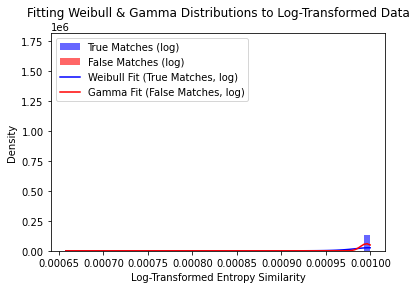

(KstestResult(statistic=0.5604278699423516, pvalue=3.759820131134698e-43, statistic_location=0.0009990239721725577, statistic_sign=-1),
 KstestResult(statistic=0.3957258741786535, pvalue=0.3202720450909504, statistic_location=0.0009972376167358052, statistic_sign=-1))

In [389]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Apply a larger shift value to avoid log(0)
shift_value = 1e-3  # Increased from 1e-5
true_scores_log = np.log(spectrum_df[spectrum_df["match_type"] == "True Match"]["entropy_similarity"] + shift_value)
false_scores_log = np.log(spectrum_df[spectrum_df["match_type"] == "False Match"]["entropy_similarity"] + shift_value)

# Ensure all values are strictly greater than 0
true_scores_log = true_scores_log[true_scores_log > 0]
false_scores_log = false_scores_log[false_scores_log > 0]

# Fit Weibull distribution to log-transformed True Matches
shape_weibull_log, loc_weibull_log, scale_weibull_log = stats.weibull_min.fit(true_scores_log, floc=0)

# Fit Gamma distribution to log-transformed False Matches
shape_gamma_log, loc_gamma_log, scale_gamma_log = stats.gamma.fit(false_scores_log, floc=0)

# Generate values for plotting
x_log = np.linspace(min(true_scores_log.min(), false_scores_log.min()), 
                     max(true_scores_log.max(), false_scores_log.max()), 100)

# Plot histogram of log-transformed entropy similarities
plt.hist(true_scores_log, bins=50, density=True, alpha=0.6, color='blue', label="True Matches (log)")
plt.hist(false_scores_log, bins=50, density=True, alpha=0.6, color='red', label="False Matches (log)")

# Overlay Weibull & Gamma fits
plt.plot(x_log, stats.weibull_min.pdf(x_log, shape_weibull_log, loc_weibull_log, scale_weibull_log), 
         'b-', label="Weibull Fit (True Matches, log)")
plt.plot(x_log, stats.gamma.pdf(x_log, shape_gamma_log, loc_gamma_log, scale_gamma_log), 
         'r-', label="Gamma Fit (False Matches, log)")

# Formatting
plt.xlabel("Log-Transformed Entropy Similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Fitting Weibull & Gamma Distributions to Log-Transformed Data")
plt.show()

# Perform Kolmogorov-Smirnov (KS) test on log-transformed data
ks_weibull_log = stats.kstest(true_scores_log, "weibull_min", args=(shape_weibull_log, loc_weibull_log, scale_weibull_log))
ks_gamma_log = stats.kstest(false_scores_log, "gamma", args=(shape_gamma_log, loc_gamma_log, scale_gamma_log))

# Output KS test results
ks_weibull_log, ks_gamma_log


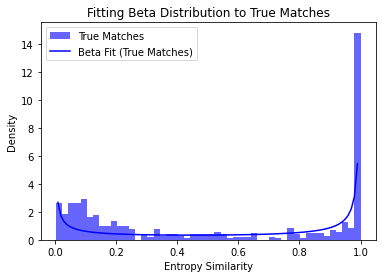

KstestResult(statistic=0.19370124218424822, pvalue=1.9605069060229933e-17, statistic_location=0.5555022358894348, statistic_sign=1)

In [390]:
# Fit a Beta Distribution to True Matches
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Extract entropy similarity values for True Matches
true_scores = spectrum_df[spectrum_df["match_type"] == "True Match"]["entropy_similarity"].values

# Ensure all values are within (0,1) for Beta fitting
eps = 1e-6  # Small shift to prevent exact 0 or 1 values
true_scores = np.clip(true_scores, eps, 1 - eps)

# Fit Beta distribution to True Matches
alpha_beta, beta_beta, loc_beta, scale_beta = stats.beta.fit(true_scores, floc=0, fscale=1)

# Generate values for plotting
x = np.linspace(0, 1, 100)

# Plot histogram of True Match entropy similarities
plt.hist(true_scores, bins=50, density=True, alpha=0.6, color='blue', label="True Matches")

# Overlay Beta fit
plt.plot(x, stats.beta.pdf(x, alpha_beta, beta_beta, loc_beta, scale_beta), 'b-', label="Beta Fit (True Matches)")

# Formatting
plt.xlabel("Entropy Similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Fitting Beta Distribution to True Matches")
plt.show()

# Perform Kolmogorov-Smirnov (KS) test on Beta fit
ks_beta = stats.kstest(true_scores, "beta", args=(alpha_beta, beta_beta, loc_beta, scale_beta))

# Output KS test results
ks_beta


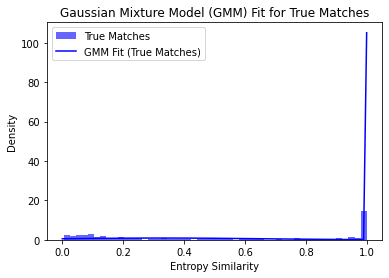

(array([0.99994075, 0.33004381]), array([0.28363887, 0.71636113]))

In [399]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Extract entropy similarity values for True Matches
true_scores = spectrum_df[spectrum_df["match_type"] == "True Match"]["entropy_similarity"].values.reshape(-1, 1)

# Fit Gaussian Mixture Model (GMM) with 2 components (to capture two subgroups)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(true_scores)

# Generate values for plotting
x = np.linspace(0, 1, 100).reshape(-1, 1)
gmm_pdf = np.exp(gmm.score_samples(x))

# Plot histogram of True Match entropy similarities
plt.hist(true_scores, bins=50, density=True, alpha=0.6, color='blue', label="True Matches")

# Overlay GMM fit
plt.plot(x, gmm_pdf, 'b-', label="GMM Fit (True Matches)")

# Formatting
plt.xlabel("Entropy Similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Gaussian Mixture Model (GMM) Fit for True Matches")
plt.show()

# Get GMM component means and weights
gmm_means = gmm.means_.flatten()
gmm_weights = gmm.weights_.flatten()

# Output GMM component information
gmm_means, gmm_weights


# Used Gamma for log-transformed tn
 - transform back to normal space for PEP calculation
# Used 2-component GMM for tp

In [407]:
import numpy as np
import scipy.stats as stats

# Ensure entropy similarity values are positive for log transformation
eps = 1e-6
entropy_similarity = spectrum_df["entropy_similarity"].values

# Step 1: Compute False Match Probability in Log Space (Gamma Distribution)
log_entropy_similarity = np.log(entropy_similarity + eps)
gamma_prob_log = stats.gamma.pdf(log_entropy_similarity, shape_gamma_log, loc_gamma_log, scale_gamma_log)

# Step 2: Convert False Match Probability Back to Normal Space
gamma_prob_normal = gamma_prob_log / entropy_similarity

# Step 3: Compute True Match Probability (Using Normal-Space GMM)
gmm_prob_normal = np.exp(gmm.score_samples(entropy_similarity.reshape(-1, 1)))

# Step 4: Compute Posterior Error Probability (PEP)
pep_values = gamma_prob_normal / (gamma_prob_normal + gmm_prob_normal)

# Store PEP values in the dataframe
spectrum_df["PEP"] = pep_values

spectrum_df["PEP"].describe()

count    600462.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: PEP, dtype: float64

In [410]:
print("Gamma Probability (log-space) Stats:", np.min(gamma_prob_log), np.max(gamma_prob_log), np.mean(gamma_prob_log))
print("Gamma Probability (normal-space) Stats:", np.min(gamma_prob_normal), np.max(gamma_prob_normal), np.mean(gamma_prob_normal))
print("GMM Probability Stats:", np.min(gmm_prob_normal), np.max(gmm_prob_normal), np.mean(gmm_prob_normal))


Gamma Probability (log-space) Stats: 0.0 0.0 0.0
Gamma Probability (normal-space) Stats: 0.0 0.0 0.0
GMM Probability Stats: 0.10601551921854807 105.31958540593679 1.040952870620609


In [411]:
print("Gamma Shape Parameter:", shape_gamma_log)
print("Gamma Location Parameter:", loc_gamma_log)
print("Gamma Scale Parameter:", scale_gamma_log)


Gamma Shape Parameter: 21796.424375531755
Gamma Location Parameter: 0
Gamma Scale Parameter: 4.567804082465764e-08


In [412]:
print("Min log entropy similarity:", np.min(log_entropy_similarity))
print("Max log entropy similarity:", np.max(log_entropy_similarity))


Min log entropy similarity: -7.40087138175071
Max log entropy similarity: 1.2384178121796405e-06


In [413]:
test_values = np.linspace(np.min(log_entropy_similarity), np.max(log_entropy_similarity), 5)
gamma_test_prob = stats.gamma.pdf(test_values, shape_gamma_log, loc_gamma_log, scale_gamma_log)
print("Test Gamma Probabilities:", gamma_test_prob)


Test Gamma Probabilities: [0. 0. 0. 0. 0.]


In [415]:
shift_value = abs(np.min(log_entropy_similarity)) + 1e-6
log_entropy_similarity_shifted = log_entropy_similarity + shift_value

# Fit Log-Normal to shifted data
shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(log_entropy_similarity_shifted, floc=0)


# Compute Log-Normal probabilities for log-transformed entropy similarity values
lognorm_prob = stats.lognorm.pdf(log_entropy_similarity, shape_lognorm, loc_lognorm, scale_lognorm)

# Convert back to normal space (apply Jacobian transformation)
lognorm_prob_normal = lognorm_prob / entropy_similarity

# Display fitted Log-Normal parameters
lognorm_params = {
    "Shape": shape_lognorm,
    "Location": loc_lognorm,
    "Scale": scale_lognorm
}

lognorm_params


{'Shape': 0.24361086992388845, 'Location': 0.0, 'Scale': 5.239981597970322}

In [417]:
ks_lognorm = stats.kstest(log_entropy_similarity_shifted, "lognorm", args=(shape_lognorm, loc_lognorm, scale_lognorm))
print("K-S Test for Log-Normal (Shifted TN):", ks_lognorm)


K-S Test for Log-Normal (Shifted TN): KstestResult(statistic=0.07819139308640288, pvalue=0.0, statistic_location=7.400873620168522, statistic_sign=1)


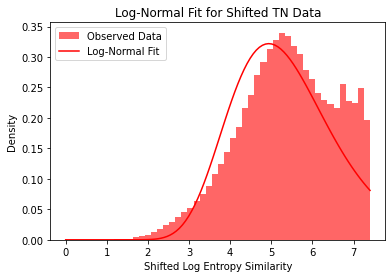

In [418]:
import matplotlib.pyplot as plt
import numpy as np

x_vals = np.linspace(min(log_entropy_similarity_shifted), max(log_entropy_similarity_shifted), 100)
plt.hist(log_entropy_similarity_shifted, bins=50, density=True, alpha=0.6, color='red', label="Observed Data")
plt.plot(x_vals, stats.lognorm.pdf(x_vals, shape_lognorm, loc_lognorm, scale_lognorm), 'r-', label="Log-Normal Fit")
plt.xlabel("Shifted Log Entropy Similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Log-Normal Fit for Shifted TN Data")
plt.show()


log normal for TN


GMM for TP

In [422]:
lognorm_prob_uncertain = lognorm_prob_normal[spectrum_df["match_type"] == "Uncertain"]


In [423]:
lognorm_prob_uncertain = np.nan_to_num(lognorm_prob_uncertain, nan=0)
gmm_prob_uncertain = np.nan_to_num(gmm_prob_uncertain, nan=0)


In [424]:
spectrum_uncertain = spectrum_df[spectrum_df["match_type"] == "Uncertain"].reset_index(drop=True)
lognorm_prob_uncertain = lognorm_prob_normal[spectrum_uncertain.index]
gmm_prob_uncertain = gmm_prob_uncertain[spectrum_uncertain.index]


In [426]:
lognorm_prob_uncertain

array([0., 0., 0., ..., 0., 0., 0.])

In [425]:
gmm_prob_uncertain

array([0.8144619 , 0.81008071, 0.80699058, ..., 0.38105877, 0.44298293,
       0.51759615])

In [427]:
print("Log-Normal Fit Parameters:")
print(f"Shape: {shape_lognorm}, Location: {loc_lognorm}, Scale: {scale_lognorm}")


Log-Normal Fit Parameters:
Shape: 0.24361086992388845, Location: 0.0, Scale: 5.239981597970322


In [428]:
print("Min Shifted Log Entropy Similarity:", np.min(log_entropy_similarity_shifted))
print("Max Shifted Log Entropy Similarity:", np.max(log_entropy_similarity_shifted))


Min Shifted Log Entropy Similarity: 1.000000000139778e-06
Max Shifted Log Entropy Similarity: 7.400873620168522


In [429]:
test_values = np.linspace(np.min(log_entropy_similarity_shifted), np.max(log_entropy_similarity_shifted), 10)
lognorm_test_prob = stats.lognorm.pdf(test_values, shape_lognorm, loc_lognorm, scale_lognorm)
print("Log-Normal Test Probabilities:", lognorm_test_prob)


Log-Normal Test Probabilities: [0.00000000e+00 5.62291300e-13 1.21567193e-05 5.56599461e-03
 8.01188711e-02 2.42672176e-01 3.21934814e-01 2.64099548e-01
 1.60957920e-01 8.10423450e-02]


In [430]:
scale_lognorm_new = np.percentile(log_entropy_similarity_shifted, 90)
shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(log_entropy_similarity_shifted, floc=0, scale=scale_lognorm_new)


In [431]:
lognorm_prob_rescaled = lognorm_prob_normal * (np.max(gmm_prob_uncertain) / np.max(lognorm_prob_normal))


<ipython-input-431-fdc6688e48d7>:1: RuntimeWarning: divide by zero encountered in scalar divide
  lognorm_prob_rescaled = lognorm_prob_normal * (np.max(gmm_prob_uncertain) / np.max(lognorm_prob_normal))
<ipython-input-431-fdc6688e48d7>:1: RuntimeWarning: invalid value encountered in multiply
  lognorm_prob_rescaled = lognorm_prob_normal * (np.max(gmm_prob_uncertain) / np.max(lognorm_prob_normal))


In [433]:
# Extract uncertain matches first to ensure consistent shape
uncertain_matches = spectrum_df[spectrum_df["match_type"] == "Uncertain"].reset_index(drop=True)

# Compute Log-Normal probabilities only for uncertain matches
lognorm_prob_uncertain = stats.lognorm.pdf(
    np.log(uncertain_matches["entropy_similarity"] + shift_value),
    shape_lognorm, loc_lognorm, scale_lognorm
)

# Compute GMM probabilities only for uncertain matches
gmm_prob_uncertain = np.exp(gmm.score_samples(uncertain_matches["entropy_similarity"].values.reshape(-1, 1)))

# Rescale Log-Normal probabilities
scaling_factor_lognorm = np.max(gmm_prob_uncertain) / np.max(lognorm_prob_uncertain)
lognorm_prob_rescaled = lognorm_prob_uncertain * scaling_factor_lognorm

# Compute PEP
pep_values_rescaled = lognorm_prob_rescaled / (lognorm_prob_rescaled + gmm_prob_uncertain)

# Assign updated PEP values back to the dataset
spectrum_df.loc[spectrum_df["match_type"] == "Uncertain", "PEP"] = pep_values_rescaled

# Show updated summary statistics of PEP values
spectrum_df["PEP"].describe()


count    600462.000000
mean          0.984706
std           0.040692
min           0.000000
25%           0.985125
50%           0.986215
75%           0.987347
max           0.998990
Name: PEP, dtype: float64

In [434]:
spectrum_df.groupby(pd.qcut(spectrum_df["entropy_similarity"], 10))["PEP"].mean()


entropy_similarity
(-0.00039000000000000005, 0.0279]    0.986866
(0.0279, 0.0497]                     0.986585
(0.0497, 0.0736]                     0.985868
(0.0736, 0.101]                      0.985179
(0.101, 0.137]                       0.984903
(0.137, 0.187]                       0.984373
(0.187, 0.269]                       0.983891
(0.269, 0.416]                       0.984942
(0.416, 0.639]                       0.988917
(0.639, 1.0]                         0.975540
Name: PEP, dtype: float64

In [435]:
print("Low PEP Examples:")
print(spectrum_df[spectrum_df["PEP"] < 0.1].head(10))

print("High PEP Examples:")
print(spectrum_df[spectrum_df["PEP"] > 0.99].head(10))



Low PEP Examples:
         wiki_id  scan                                         splash  \
286    aPUDE1U/8     8  splash10-0006-9100000000-b60c6c104cfc41a9c1e9   
425   aPUDE1U/12    12  splash10-004i-5900000000-a5f82ad9600221fb0c61   
704   aPUDE1U/22    22  splash10-03di-0090000000-3f95c7479d6ee1ee5400   
926   aPUDE1U/33    33  splash10-000i-9500000000-ccc26717ce33836c3fe8   
1206  aPUDE1U/40    40  splash10-00dr-9100000000-49c64e268302238c6a1d   
1616  aPUDE1U/49    49  splash10-001i-0900000000-ed3deb09a7fadbc17ce3   
1755  aPUDE1U/51    51  splash10-0bvr-9600000000-0839ec8560a64b14a68b   
1794  aPUDE1U/55    55  splash10-0a4i-1900000000-62b77133de16a2f76d83   
2180  aPUDE1U/62    62  splash10-03dr-6900000000-f601060646f181f74136   
2339  aPUDE1U/63    63  splash10-03dr-6900000000-42630bb291565ad1e334   

                                  target_name target_adduct          spec_uid  \
286   urocanic acid_#04_[M-H]-_137.0438_55.92                1458903631924920   
425          1_D

In [436]:
# Reduce Log-Normal probabilities further by introducing an additional scaling factor
adjustment_factor = 0.1  # Reduce Log-Normal probabilities by 90%

# Apply additional scaling to Log-Normal probabilities
lognorm_prob_rescaled_adjusted = lognorm_prob_rescaled * adjustment_factor

# Compute new PEP using further adjusted Log-Normal probabilities
pep_values_adjusted = lognorm_prob_rescaled_adjusted / (lognorm_prob_rescaled_adjusted + gmm_prob_uncertain)

# Assign updated PEP values back to the dataset
spectrum_df.loc[spectrum_df["match_type"] == "Uncertain", "PEP"] = pep_values_adjusted

# Show updated summary statistics of PEP values
spectrum_df["PEP"].describe()


count    600462.000000
mean          0.882626
std           0.060399
min           0.000000
25%           0.868814
50%           0.877363
75%           0.886409
max           0.989990
Name: PEP, dtype: float64

In [437]:
spectrum_df.groupby(pd.qcut(spectrum_df["entropy_similarity"], 10))["PEP"].mean()


entropy_similarity
(-0.00039000000000000005, 0.0279]    0.886653
(0.0279, 0.0497]                     0.882631
(0.0497, 0.0736]                     0.878426
(0.0736, 0.101]                      0.874247
(0.101, 0.137]                       0.870370
(0.137, 0.187]                       0.866361
(0.187, 0.269]                       0.863761
(0.269, 0.416]                       0.870589
(0.416, 0.639]                       0.904306
(0.639, 1.0]                         0.928917
Name: PEP, dtype: float64

# try gmm for both TP and TN?

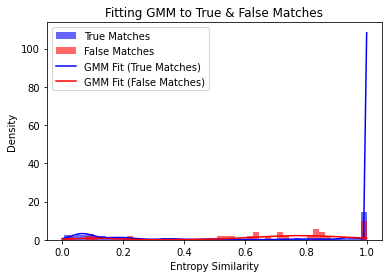

(KstestResult(statistic=0.139, pvalue=3.328669923650047e-06, statistic_location=1.000000238418579, statistic_sign=1),
 KstestResult(statistic=0.11730769230769231, pvalue=0.8359293336374896, statistic_location=0.9968286541225599, statistic_sign=-1))

In [460]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Extract entropy similarity values for True and False Matches
true_scores = spectrum_df[spectrum_df["match_type"] == "True Match"]["entropy_similarity"].values.reshape(-1, 1)
false_scores = spectrum_df[spectrum_df["match_type"] == "False Match"]["entropy_similarity"].values.reshape(-1, 1)

# Fit Gaussian Mixture Model (GMM) for True Matches (assume 2 components)
gmm_tp = GaussianMixture(n_components=7, random_state=42)
gmm_tp.fit(true_scores)

# Fit Gaussian Mixture Model (GMM) for False Matches (assume 2 components)
gmm_tn = GaussianMixture(n_components=2, random_state=42)
gmm_tn.fit(false_scores)

# Generate values for plotting
x = np.linspace(0, 1, 100).reshape(-1, 1)
gmm_tp_pdf = np.exp(gmm_tp.score_samples(x))
gmm_tn_pdf = np.exp(gmm_tn.score_samples(x))

# Plot histogram of entropy similarities
plt.hist(true_scores, bins=50, density=True, alpha=0.6, color='blue', label="True Matches")
plt.hist(false_scores, bins=50, density=True, alpha=0.6, color='red', label="False Matches")

# Overlay GMM fits
plt.plot(x, gmm_tp_pdf, 'b-', label="GMM Fit (True Matches)")
plt.plot(x, gmm_tn_pdf, 'r-', label="GMM Fit (False Matches)")

# Formatting
plt.xlabel("Entropy Similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Fitting GMM to True & False Matches")
plt.show()

# Compute Kolmogorov-Smirnov (KS) test for model validation
ks_gmm_tp = stats.kstest(true_scores.flatten(), gmm_tp.sample(1000)[0].flatten())
ks_gmm_tn = stats.kstest(false_scores.flatten(), gmm_tn.sample(1000)[0].flatten())

# Print K-S test results
ks_gmm_tp, ks_gmm_tn


In [461]:
# Fit Gaussian Mixture Model (GMM) for True Matches (TP) with 7 components
gmm_tp_7 = GaussianMixture(n_components=7, random_state=42)
gmm_tp_7.fit(true_scores.reshape(-1, 1))

# Fit Gaussian Mixture Model (GMM) for False Matches (TN) with 2 components
gmm_tn_2 = GaussianMixture(n_components=2, random_state=42)
gmm_tn_2.fit(false_scores.reshape(-1, 1))

# Compute probabilities for uncertain matches
uncertain_matches = spectrum_df[spectrum_df["match_type"] == "Uncertain"].reset_index(drop=True)
uncertain_entropy = uncertain_matches["entropy_similarity"].values.reshape(-1, 1)

# Compute probabilities under GMM models
gmm_tp_prob = np.exp(gmm_tp_7.score_samples(uncertain_entropy))
gmm_tn_prob = np.exp(gmm_tn_2.score_samples(uncertain_entropy))

# Compute Posterior Error Probability (PEP)
pep_values = gmm_tn_prob / (gmm_tn_prob + gmm_tp_prob)

# Assign PEP values to the dataset
spectrum_df.loc[spectrum_df["match_type"] == "Uncertain", "PEP"] = pep_values

# Show updated summary statistics of PEP values
spectrum_df["PEP"].describe()


count    600462.000000
mean          0.325665
std           0.218399
min           0.000000
25%           0.187215
50%           0.239192
75%           0.362637
max           0.928039
Name: PEP, dtype: float64

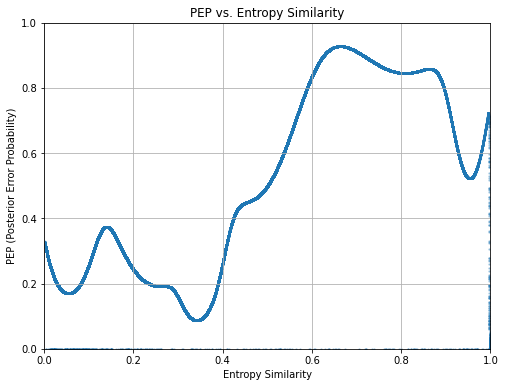

In [462]:
import matplotlib.pyplot as plt

# Scatter plot of PEP vs. Entropy Similarity
plt.figure(figsize=(8, 6))
plt.scatter(spectrum_df["entropy_similarity"], spectrum_df["PEP"], alpha=0.3, s=2)
plt.xlabel("Entropy Similarity")
plt.ylabel("PEP (Posterior Error Probability)")
plt.title("PEP vs. Entropy Similarity")
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.grid(True)
plt.show()


In [468]:
from statsmodels.stats.multitest import multipletests

# Sort the dataset by PEP in ascending order
spectrum_df = spectrum_df.sort_values(by="PEP")

# Apply Benjamini-Hochberg (BH) correction to control FDR
_, fdr_corrected_pep, _, _ = multipletests(spectrum_df["PEP"], method='fdr_bh')

# Add FDR-corrected values to the DataFrame
spectrum_df["FDR_Corrected_PEP"] = fdr_corrected_pep

# Determine the highest PEP where FDR remains below a given threshold (e.g., 0.05)
fdr_threshold = 0.01
accepted_matches = spectrum_df[spectrum_df["FDR_Corrected_PEP"] <= fdr_threshold]



(542, 24)

In [469]:
print(accepted_matches)

             wiki_id  scan                                         splash  \
370293  aEKJ9AS/6620  6620  splash10-004i-2920000000-592789bec7c6b5036873   
532057  aEKJ9AS/9617  9617  splash10-014i-3090000000-7f6d2a9144fd8a4a409d   
325958  aEKJ9AS/5715  5715  splash10-00di-1900000000-a9227f89fde23157b6ab   
245120  aEKJ9AS/3785  3785  splash10-00di-3900000000-2b5e99aedec9e47d4bf5   
277640  aEKJ9AS/4265  4265  splash10-00dr-5900000000-b0920e29c150ec108f7f   
...              ...   ...                                            ...   
128071  aEKJ9AS/1446  1446  splash10-001r-6900000000-f88a30b9179b0292b2a7   
68344    aEKJ9AS/428   428  splash10-06si-0950000000-f042f034ff6bc1ee7d61   
413904  aEKJ9AS/7492  7492  splash10-00di-4900000000-eb500871a39b536c9068   
118670  aEKJ9AS/1290  1290  splash10-001r-6900000000-f076707a986a074ecbce   
333534  aEKJ9AS/5919  5919  splash10-004i-4910000000-01bf7fa09fbc6403b8f4   

                                              target_name target_adduct  \


In [470]:
spectrum_df

,wiki_id,scan,splash,target_name,target_adduct,spec_uid,charge,precursor_mz,entropy,rt_normalized,...,library_adduct,library_rt,library_smiles,library_spec_uid,library_precursor_mz,entropy_similarity,source,match_type,PEP,FDR_Corrected_PEP
370293,aEKJ9AS/6620,6620,splash10-004i-2920000000-592789bec7c6b5036873,"yy_3,7-dihydroxy-12-oxo-24-oxocholan-24-yl)ami...",[M-H2O+H]+,1230784689210650,1,496.272767,4.225140,95.603831,...,[M-H2O+H]+,79.581942,CC(CCC(=O)NCCS(=O)(=O)O)C1CCC2C1(C(=O)CC3C2C(C...,1761069805170681,496.2728371147752,0.832915,annotation_library,True Match,0.000000,0.000000
532057,aEKJ9AS/9617,9617,splash10-014i-3090000000-7f6d2a9144fd8a4a409d,myristamidopropyl betaine,[M]+,888925377216797,1,371.326747,1.463809,54.414633,...,[M]+,42.412142,CCCCCCCCCCCCCC(O)=NCCC[N+](C)(C)CC(=O)O,3740618781606747,371.3266748591588,0.673479,annotation_library,False Match,0.000000,0.000000
325958,aEKJ9AS/5715,5715,splash10-00di-1900000000-a9227f89fde23157b6ab,unknown_170.0924_56.17,,4419568713360159,1,170.092390,2.323289,56.442112,...,[M+H]+,138.598979,CN1C=NC=C1CC(C(=O)O)N,1795134946070011,170.09241844593586,0.022840,annotation_library,True Match,0.000000,0.000000
245120,aEKJ9AS/3785,3785,splash10-00di-3900000000-2b5e99aedec9e47d4bf5,unknown_172.1331_69.67,,3590088726662349,1,172.133082,3.173167,69.925455,...,[M+H]+,90.734410,C1CCC(CC1)(CC(=O)O)CN,2289071627643493,172.13313265638308,0.189605,annotation_library,True Match,0.000000,0.000000
277640,aEKJ9AS/4265,4265,splash10-00dr-5900000000-b0920e29c150ec108f7f,unknown_171.1128_104.19,,252781914207234,1,171.112769,1.380626,104.552630,...,[M+H]+,19.425135,CCC(C(=O)N)N1CCCC1=O,4233949782830083,171.11273806144936,0.046452,annotation_library,True Match,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41689,aEKJ9AS/72,72,splash10-004r-5900000000-0ee7b21e55d2a9b17274,melamine minor,[M+H]+,2598374323879137,1,127.072659,0.820967,68.769331,...,[M+H]+,58.440675,C1(=NC(=NC(=N1)N)N)N,4253093087427110,127.0726522273638,0.663419,annotation_library,Uncertain,0.928039,0.928039
593746,aEKJ9AS/11314,11314,splash10-014r-2900000000-140feec2f054fede840d,unknown_165.0547_69.99,,2144609306025830,1,165.054679,2.098956,70.330314,...,[M+H-H2O]+,NaN,O=C(O)CCc1ccc(O)c(O)c1,None,165.0540708,0.663429,reference_library,Uncertain,0.928039,0.928039
51668,aEKJ9AS/183,183,splash10-0f8i-5900000000-1f4b4248d2a42b4e08ab,LPC 16:0,[M+H]+,3348902635709146,1,496.339420,1.955049,82.188524,...,M+H,NaN,,None,496.34,0.663452,reference_library,Uncertain,0.928039,0.928039
414570,aEKJ9AS/7500,7500,splash10-001r-9830000000-cf6cf9d7e7482ed4006e,unknown_262.1033_137.89,,1389894826847074,1,262.103256,3.301866,138.324721,...,[M+H]+,NaN,NC(=O)CCC(N)C(=O)NC(CC(=O)O)C(=O)O,None,262.1033612,0.663435,reference_library,Uncertain,0.928039,0.928039


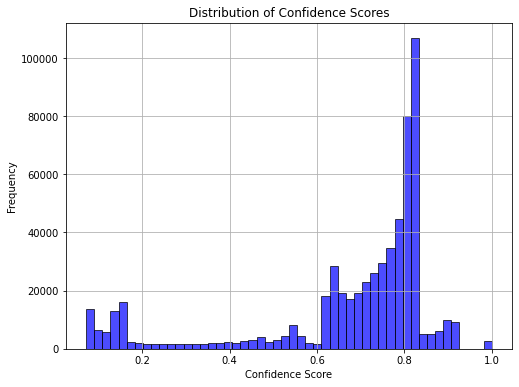

In [475]:
# Compute Confidence Score as (1 - PEP) and add it to the dataset
spectrum_df["Confidence_Score"] = 1 - spectrum_df["PEP"]

# Visualize the distribution of Confidence Scores
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(spectrum_df["Confidence_Score"], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Distribution of Confidence Scores")
plt.grid(True)
plt.show()


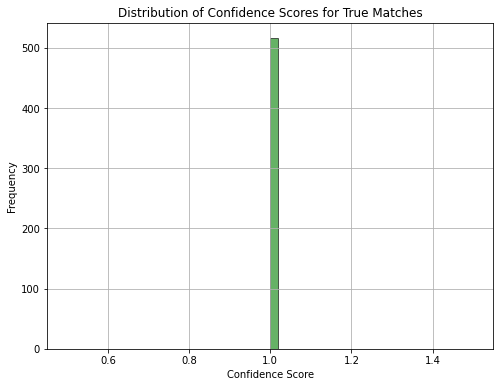

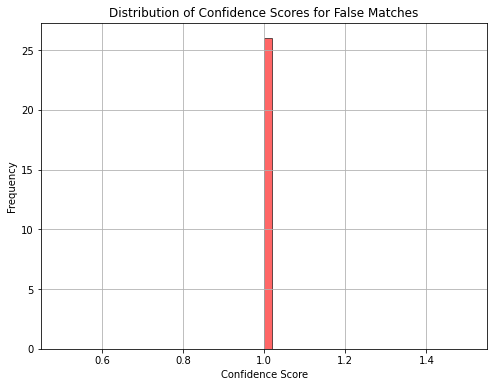

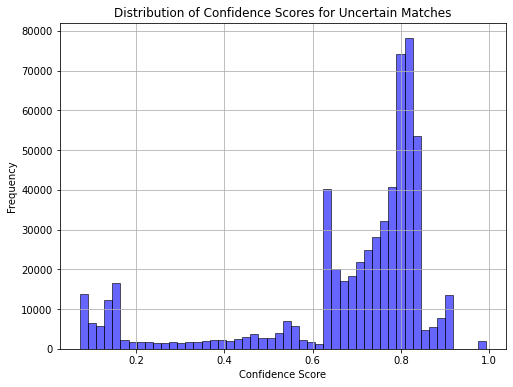

In [479]:
import matplotlib.pyplot as plt

# Plot histogram of Confidence Scores for True Matches
plt.figure(figsize=(8, 6))
plt.hist(true_match_scores, bins=50, alpha=0.6, color='green', edgecolor='black')
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Distribution of Confidence Scores for True Matches")
plt.grid(True)
plt.show()

# Plot histogram of Confidence Scores for False Matches
plt.figure(figsize=(8, 6))
plt.hist(false_match_scores, bins=50, alpha=0.6, color='red', edgecolor='black')
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Distribution of Confidence Scores for False Matches")
plt.grid(True)
plt.show()

# Plot histogram of Confidence Scores for Uncertain Matches
plt.figure(figsize=(8, 6))
plt.hist(uncertain_match_scores, bins=50, alpha=0.6, color='blue', edgecolor='black')
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Distribution of Confidence Scores for Uncertain Matches")
plt.grid(True)
plt.show()


In [483]:
# Extract entropy similarity values for False Matches
false_match_entropy = spectrum_df[spectrum_df["match_type"] == "False Match"]["entropy_similarity"].values.reshape(-1, 1)

# Compute probabilities under the GMM model for False Matches
gmm_tn_prob = np.exp(gmm_tn_2.score_samples(false_match_entropy))

# Display min, max, and summary of GMM probabilities for False Matches
gmm_tn_prob_summary = {
    "Min GMM Probability for False Matches": np.min(gmm_tn_prob),
    "Max GMM Probability for False Matches": np.max(gmm_tn_prob),
    "Mean GMM Probability for False Matches": np.mean(gmm_tn_prob)
}

gmm_tn_prob_summary


{'Min GMM Probability for False Matches': 0.21936349559798027,
 'Max GMM Probability for False Matches': 2.1236173927207145,
 'Mean GMM Probability for False Matches': 1.3117485839319107}